reference
[https://ccrma.stanford.edu/~jos/sasp/Overlap_Add_OLA_STFT_Processing.html](https://ccrma.stanford.edu/~jos/sasp/Overlap_Add_OLA_STFT_Processing.html)
[https://ccrma.stanford.edu/~jos/sasp/Filter_Bank_Summation_FBS.html](https://ccrma.stanford.edu/~jos/sasp/Filter_Bank_Summation_FBS.html)

# 时变核心卷积
1. 标准R=M矩形窗+两倍零填充
2. R=M/2临界采样+两倍零填充
3. R=M/4抗混叠采样+两倍零填充

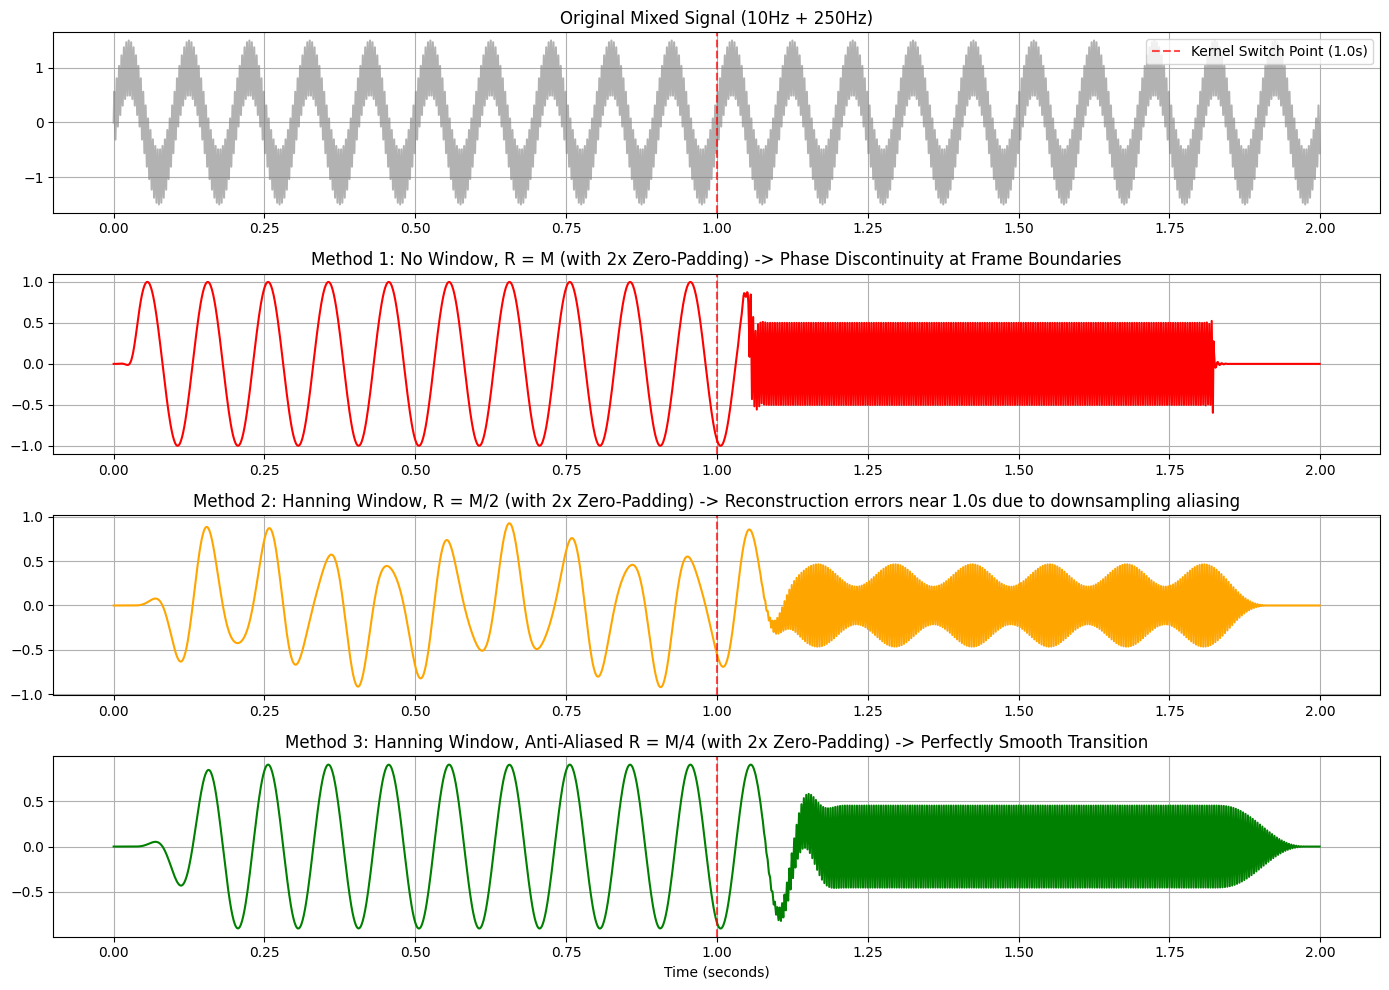

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin

# ==========================================
# 1. 基础参数设置与信号生成
# ==========================================
np.random.seed(123)
fs = 1000  # 采样率
duration = 2.0  # 信号时长
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# 输入信号：低频(10Hz) + 高频(250Hz) 混合
x = np.sin(2 * np.pi * 10 * t) + 0.5 * np.sin(2 * np.pi * 250 * t)

M = 256  # 帧长 / 窗长
fft_size = M * 2  # 【统一约束】所有方法全部进行 2 倍零填充
num_samples = len(x)


# ==========================================
# 2. 时变内核生成函数 (1.0秒处突变)
# ==========================================
def get_time_varying_kernel(sample_idx):
    num_taps = 63  # 核长度 K
    if sample_idx < num_samples // 2:
        return firwin(num_taps, 50, fs=fs, pass_zero="lowpass")  # 前半段低通
    else:
        return firwin(num_taps, 150, fs=fs, pass_zero="highpass")  # 后半段高通


# ==========================================
# 方法一：不加窗，硬推进 (R = M) + 2倍零填充
# ==========================================
y_method1 = np.zeros(num_samples + fft_size)
R1 = M

for n in range(0, num_samples - M, R1):
    x_frame = x[n : n + M]
    h = get_time_varying_kernel(n)

    # 2倍零填充 FFT
    X_f = np.fft.fft(x_frame, n=fft_size)
    H_f = np.fft.fft(h, n=fft_size)
    y_frame = np.fft.ifft(X_f * H_f).real

    # 矩形窗 OLA 拼接
    y_method1[n : n + fft_size] += y_frame

# ==========================================
# 方法二：加汉宁窗，普通重建步长 (R = M/2) + 2倍零填充
# ==========================================
y_method2 = np.zeros(num_samples + fft_size)
R2 = M // 2
win2 = np.hanning(M)

for n in range(0, num_samples - M, R2):
    x_frame = x[n : n + M] * win2
    h = get_time_varying_kernel(n)

    X_f = np.fft.fft(x_frame, n=fft_size)
    H_f = np.fft.fft(h, n=fft_size)
    y_frame = np.fft.ifft(X_f * H_f).real

    # 汉宁窗 50% 重叠时，重叠累加的直流增益和为 1.0 (由于两端加窗，这里不需要额外归一化)
    # 但由于这相当于对时变序列做了 R=M/2 的下采样，在突变点抗混叠性能较弱
    y_method2[n : n + fft_size] += y_frame * np.pad(win2, (0, fft_size - M))

# ==========================================
# 方法三：加汉宁窗，抗混叠步长 (R = M/4) + 2倍零填充
# ==========================================
y_method3 = np.zeros(num_samples + fft_size * 2)
R3 = M // 4
win3 = np.hanning(M)

for n in range(0, num_samples - M, R3):
    x_frame = x[n : n + M] * win3
    h = get_time_varying_kernel(n)

    X_f = np.fft.fft(x_frame, n=fft_size)
    H_f = np.fft.fft(h, n=fft_size)
    y_frame = np.fft.ifft(X_f * H_f).real

    # 75% 重叠（过采样一倍）时，汉宁窗 OLA 的固有的常数增益和为 1.5
    # 我们乘以合成窗并除去增益常数
    y_method3[n : n + fft_size] += (y_frame * np.pad(win3, (0, fft_size - M))) * (
        1.0 / 1.5
    )

# 裁剪长度
y_method1 = y_method1[:num_samples]
y_method2 = y_method2[:num_samples]
y_method3 = y_method3[:num_samples]

# ==========================================
# 3. 绘图输出
# ==========================================
plt.figure(figsize=(14, 10))

# 原始输入
plt.subplot(4, 1, 1)
plt.plot(t, x, color="gray", alpha=0.6)
plt.title("Original Mixed Signal (10Hz + 250Hz)")
plt.axvline(
    x=1.0, color="red", linestyle="--", alpha=0.7, label="Kernel Switch Point (1.0s)"
)
plt.legend()
plt.grid(True)

# 方法一
plt.subplot(4, 1, 2)
plt.plot(t, y_method1, color="red")
plt.title(
    "Method 1: No Window, R = M (with 2x Zero-Padding) -> Phase Discontinuity at Frame Boundaries"
)
plt.axvline(x=1.0, color="red", linestyle="--", alpha=0.7)
plt.grid(True)

# 方法二
plt.subplot(4, 1, 3)
plt.plot(t, y_method2, color="orange")
plt.title(
    "Method 2: Hanning Window, R = M/2 (with 2x Zero-Padding) -> Reconstruction errors near 1.0s due to downsampling aliasing"
)
plt.axvline(x=1.0, color="red", linestyle="--", alpha=0.7)
plt.grid(True)

# 方法三
plt.subplot(4, 1, 4)
plt.plot(t, y_method3, color="green")
plt.title(
    "Method 3: Hanning Window, Anti-Aliased R = M/4 (with 2x Zero-Padding) -> Perfectly Smooth Transition"
)
plt.axvline(x=1.0, color="red", linestyle="--", alpha=0.7)
plt.xlabel("Time (seconds)")
plt.grid(True)

plt.tight_layout()
plt.show()

# OLA vs WOLA
R=M/2 hann vs hann^2 vs sqrt(hann) 重建

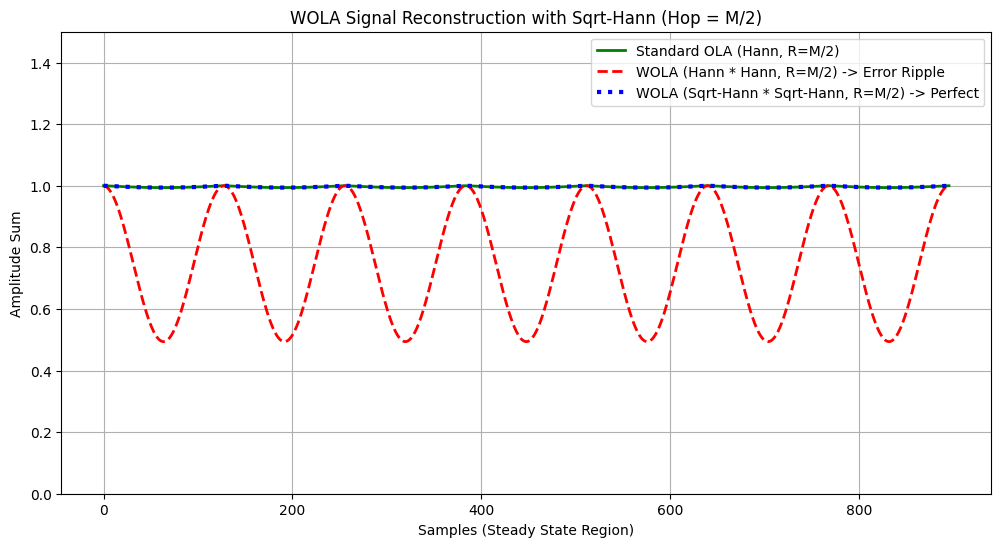

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

M = 256  # 窗长
R = M // 2  # Hop Size (50% 重叠)
num_frames = 10  # 模拟帧数
total_len = R * (num_frames - 1) + M

# 构造一个全 1 的直流信号
x_ones = np.ones(total_len)

# 准备三个用于累加的数组
ola_result = np.zeros(total_len)
wola_result = np.zeros(total_len)
wola_sqrt_result = np.zeros(total_len)  # 新增：用于验证 sqrt(hann)

# 标准的 Hann 窗与开根号 Hann 窗
win_hann = np.hanning(M)
win_root_hann = np.sqrt(win_hann)  # 新增：开根号 Hann 窗

for f in range(num_frames):
    start = f * R
    end = start + M

    # 模拟该帧的输入信号段
    x_frame = x_ones[start:end]

    # 1. 模拟单次 OLA (仅分析端加标准 Hann 窗)
    ola_result[start:end] += x_frame * win_hann

    # 2. 模拟 WOLA (分析端加标准 Hann * 合成端加标准 Hann) -> 相当于 win_hann^2
    wola_result[start:end] += x_frame * win_hann * win_hann

    # 3. 新增：模拟 WOLA (分析端加根号 Hann * 合成端加根号 Hann)
    # 物理意义：两端相乘 => win_root_hann * win_root_hann = win_hann
    wola_sqrt_result[start:end] += x_frame * win_root_hann * win_root_hann

# 裁剪掉两端未完全重叠的部分，只观察中间的稳态重建
valid_start = M
valid_end = total_len - M

plt.figure(figsize=(12, 6))
plt.plot(
    ola_result[valid_start:valid_end],
    label="Standard OLA (Hann, R=M/2)",
    color="green",
    linewidth=2,
)
plt.plot(
    wola_result[valid_start:valid_end],
    label="WOLA (Hann * Hann, R=M/2) -> Error Ripple",
    color="red",
    linestyle="--",
    linewidth=2,
)
plt.plot(
    wola_sqrt_result[valid_start:valid_end],
    label="WOLA (Sqrt-Hann * Sqrt-Hann, R=M/2) -> Perfect",
    color="blue",
    linestyle=":",
    linewidth=3,
)

plt.title("WOLA Signal Reconstruction with Sqrt-Hann (Hop = M/2)")
plt.xlabel("Samples (Steady State Region)")
plt.ylabel("Amplitude Sum")
plt.ylim(0, 1.5)
plt.grid(True)
plt.legend()
plt.show()

X(hann) vs X(sqrt(hann))

C:\Users\Kawai\AppData\Local\Temp\ipykernel_21624\4372966.py:15: RuntimeWarning: divide by zero encountered in log10
  hann_spec = 20 * np.log10(hann_spec / np.max(hann_spec)) # 转换为 dB
C:\Users\Kawai\AppData\Local\Temp\ipykernel_21624\4372966.py:18: RuntimeWarning: divide by zero encountered in log10
  root_hann_spec = 20 * np.log10(root_hann_spec / np.max(root_hann_spec))


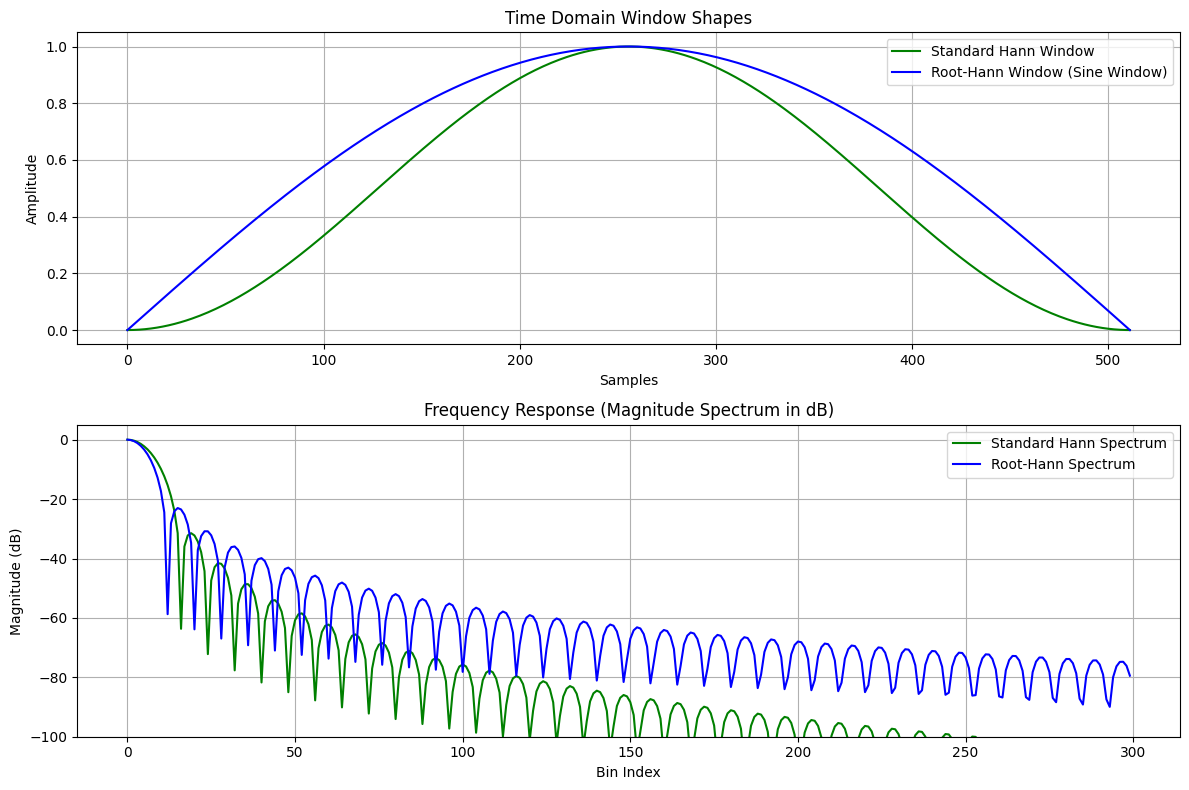

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

M = 512
fft_size = 4096  # 高分辨率 FFT 以清晰观察旁瓣

# 构造两种窗函数
win_hann = np.hanning(M)
win_root_hann = np.sqrt(win_hann)  # 开根号

# 计算频谱并归一化
fft_freq = np.fft.rfftfreq(fft_size, d=1 / fft_size)

hann_spec = np.abs(np.fft.rfft(win_hann, n=fft_size))
hann_spec = 20 * np.log10(hann_spec / np.max(hann_spec))  # 转换为 dB

root_hann_spec = np.abs(np.fft.rfft(win_root_hann, n=fft_size))
root_hann_spec = 20 * np.log10(root_hann_spec / np.max(root_hann_spec))

# 绘图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# 时域波形对比
ax1.plot(win_hann, label="Standard Hann Window", color="green")
ax1.plot(win_root_hann, label="Root-Hann Window (Sine Window)", color="blue")
ax1.set_title("Time Domain Window Shapes")
ax1.set_xlabel("Samples")
ax1.set_ylabel("Amplitude")
ax1.grid(True)
ax1.legend()

# 频域对数谱对比
ax2.plot(fft_freq[:300], hann_spec[:300], label="Standard Hann Spectrum", color="green")
ax2.plot(fft_freq[:300], root_hann_spec[:300], label="Root-Hann Spectrum", color="blue")
ax2.set_title("Frequency Response (Magnitude Spectrum in dB)")
ax2.set_xlabel("Bin Index")
ax2.set_ylabel("Magnitude (dB)")
ax2.set_ylim(-100, 5)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

M=4 hann^2 重建

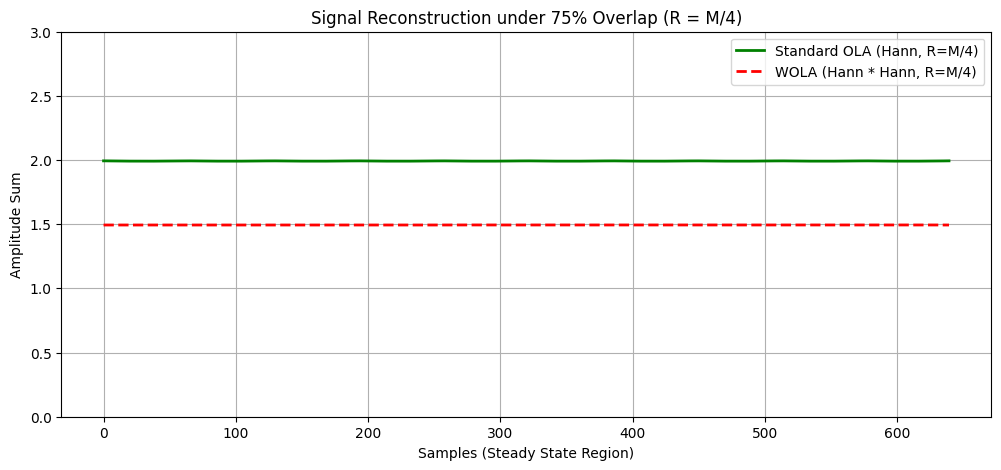

标准 OLA (R=M/4) 中间的恒定值 = 1.99 (理论值: 2.0)
WOLA     (R=M/4) 中间的恒定值 = 1.49 (理论值: 1.5)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

M = 256  # 窗长
R = M // 4  # Hop Size (75% 重叠)
num_frames = 15  # 帧数需要多一点以观察中间平稳段
total_len = R * (num_frames - 1) + M

# 构造全 1 的直流输入信号
x_ones = np.ones(total_len)

# 准备累加数组
ola_result = np.zeros(total_len)
wola_result = np.zeros(total_len)

# 标准 Hann 窗
win_hann = np.hanning(M)

for f in range(num_frames):
    start = f * R
    end = start + M

    x_frame = x_ones[start:end]

    # 1. 单次 OLA (R = M/4)
    # Hann 窗在 75% 重叠下，振幅累加的常数直流增益是 2.0
    ola_result[start:end] += x_frame * win_hann

    # 2. WOLA 两次加窗 (R = M/4)
    # Hann 窗的平方在 75% 重叠下，能量累加的常数直流增益刚好是 1.5
    wola_result[start:end] += x_frame * win_hann * win_hann

# 移除两端未完全重叠的边缘淡入淡出区域，只观察中间的稳态重建部分
valid_start = M
valid_end = total_len - M

plt.figure(figsize=(12, 5))
plt.plot(
    ola_result[valid_start:valid_end],
    label="Standard OLA (Hann, R=M/4)",
    color="green",
    linewidth=2,
)
plt.plot(
    wola_result[valid_start:valid_end],
    label="WOLA (Hann * Hann, R=M/4)",
    color="red",
    linestyle="--",
    linewidth=2,
)

plt.title("Signal Reconstruction under 75% Overlap (R = M/4)")
plt.xlabel("Samples (Steady State Region)")
plt.ylabel("Amplitude Sum")
# 为了方便直观对比形状是否平坦，将各自的增益归一化到 1.0 附近
plt.ylim(0, 3.0)
plt.grid(True)
plt.legend()
plt.show()

# 打印实际累加出的常数值
print(f"标准 OLA (R=M/4) 中间的恒定值 = {ola_result[total_len // 2]:.2f} (理论值: 2.0)")
print(
    f"WOLA     (R=M/4) 中间的恒定值 = {wola_result[total_len // 2]:.2f} (理论值: 1.5)"
)

# 不同窗的完美重建(无抗混叠)
hamm注意要把在边界点的两个采样的值/2

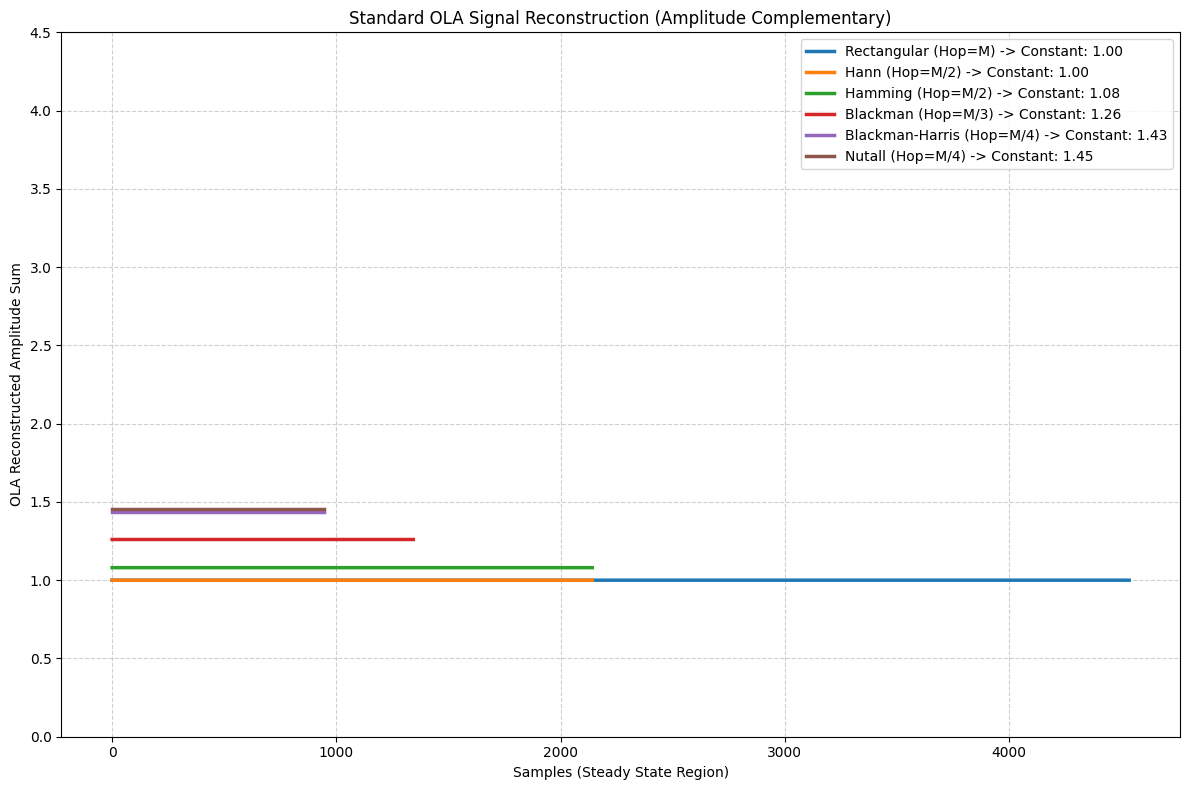

--- 传统 OLA 完美重建精度验证 (稳态纹波大小) ---
Window & Configuration         | Constant Value  | Ripple Peak-to-Peak 
------------------------------------------------------------------------
Rectangular (Hop=M)            | 1.00            | 0.0e+00             
Hann (Hop=M/2)                 | 1.00            | 5.6e-16             
Hamming (Hop=M/2)              | 1.08            | 6.7e-16             
Blackman (Hop=M/3)             | 1.26            | 8.9e-16             
Blackman-Harris (Hop=M/4)      | 1.43            | 8.9e-16             
Nutall (Hop=M/4)               | 1.45            | 1.1e-15             


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

# ==========================================
# 1. 基础参数设置
# ==========================================
M = 252  # 窗长（选择 252 是因为它能同时被 2, 3, 4 整除，方便演示）
num_frames = 20  # 模拟帧数

# 使用 periodic=True (sym=False) 保证离散 OLA 的完美闭合
win_rect = np.ones(M)
win_hann = windows.hann(M, sym=False)
win_hamm = windows.hamming(M, sym=False)
win_black = windows.blackman(M, sym=False)
win_bh = windows.blackmanharris(M, sym=False)
win_nu = windows.nuttall(M, sym=False)


# ==========================================
# 2. OLA 仿真函数 (单次加窗)
# ==========================================
def test_ola(win, hop_size):
    R = hop_size
    total_len = R * (num_frames - 1) + M
    result = np.zeros(total_len)

    for f in range(num_frames):
        start = f * R
        end = start + M
        # 标准 OLA：只在分析端乘以一次窗，合成端直接重叠累加
        result[start:end] += win

    # 截取中间完全重叠的稳态区域
    return result[M : total_len - M]


# ==========================================
# 3. 针对不同窗函数，使用其【刚好完美重建】的最小重叠度进行测试
# ==========================================
results_ola = {
    "Rectangular (Hop=M)": test_ola(win_rect, hop_size=M),
    "Hann (Hop=M/2)": test_ola(win_hann, hop_size=M // 2),
    "Hamming (Hop=M/2)": test_ola(win_hamm, hop_size=M // 2),
    "Blackman (Hop=M/3)": test_ola(win_black, hop_size=M // 3),
    "Blackman-Harris (Hop=M/4)": test_ola(win_bh, hop_size=M // 4),
    "Nutall (Hop=M/4)": test_ola(win_nu, hop_size=M // 4),
}

# ==========================================
# 4. 使用 Matplotlib 绘图输出
# ==========================================
plt.figure(figsize=(12, 8))

for name, data in results_ola.items():
    plt.plot(data, label=f"{name} -> Constant: {np.mean(data):.2f}", linewidth=2.5)

plt.title("Standard OLA Signal Reconstruction (Amplitude Complementary)")
plt.xlabel("Samples (Steady State Region)")
plt.ylabel("OLA Reconstructed Amplitude Sum")
plt.ylim(0, 4.5)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# ==========================================
# 5. 打印纹波精度验证
# ==========================================
print("--- 传统 OLA 完美重建精度验证 (稳态纹波大小) ---")
print(
    f"{'Window & Configuration':<30} | {'Constant Value':<15} | {'Ripple Peak-to-Peak':<20}"
)
print("-" * 72)
for name, data in results_ola.items():
    ripple = np.max(data) - np.min(data)
    print(f"{name:<30} | {np.mean(data):<15.2f} | {ripple:<20.1e}")

# 各窗函数的频谱与全部零点位置
COLA (Constant Overlap-Add) 与 Nyquist(N) 的对偶关系

C:\Users\Kawai\AppData\Local\Temp\ipykernel_21624\2534089543.py:110: UserWarning: Glyph 8596 (\N{LEFT RIGHT ARROW}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()


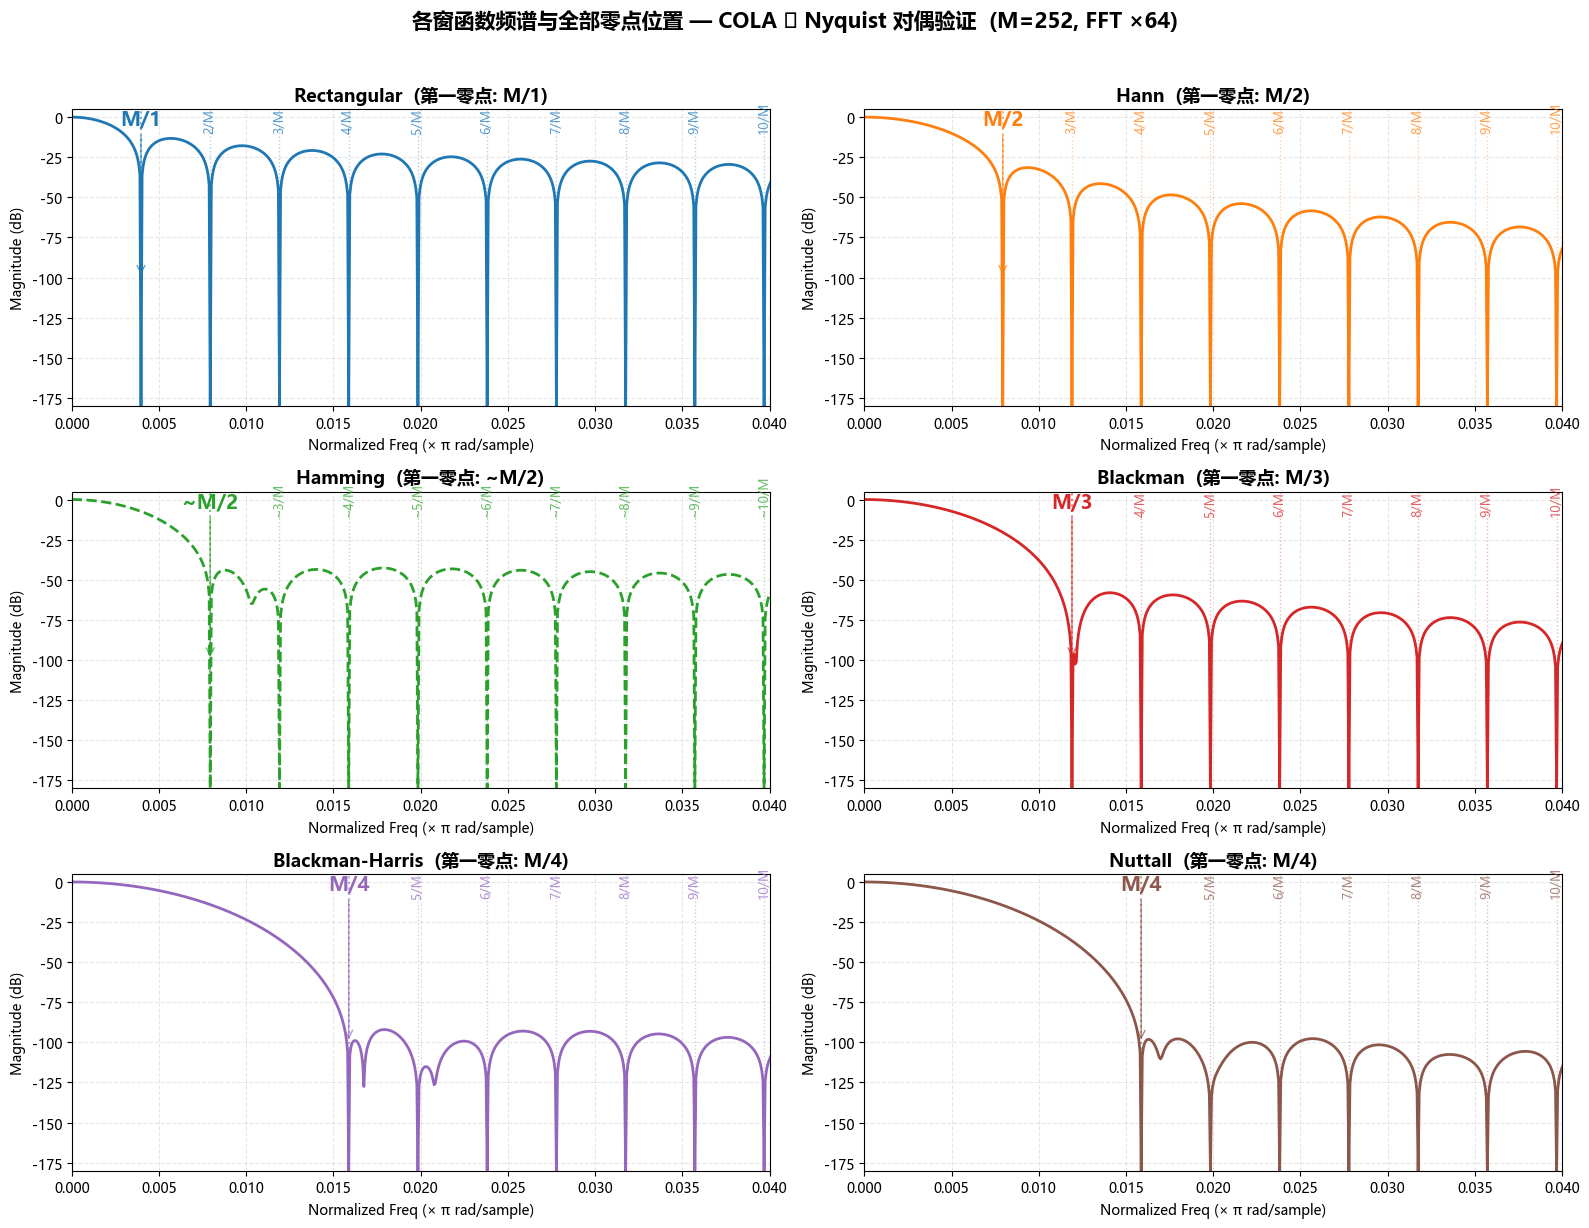

--- 各窗函数理论零点位置 (f = k / M) ---
Window               | Norm Freq    | Label    | First?
--------------------------------------------------
Rectangular          | 0.003968     | M/1      | ★     
Rectangular          | 0.007937     | 2/M      |       
Rectangular          | 0.011905     | 3/M      |       
Rectangular          | 0.015873     | 4/M      |       
Rectangular          | 0.019841     | 5/M      |       
Rectangular          | 0.023810     | 6/M      |       
Rectangular          | 0.027778     | 7/M      |       
Rectangular          | 0.031746     | 8/M      |       
Rectangular          | 0.035714     | 9/M      |       
Rectangular          | 0.039683     | 10/M     |       
Hann                 | 0.007937     | M/2      | ★     
Hann                 | 0.011905     | 3/M      |       
Hann                 | 0.015873     | 4/M      |       
Hann                 | 0.019841     | 5/M      |       
Hann                 | 0.023810     | 6/M      |       
Hann                 |

In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

# ==========================================
# 0. matplotlib 中文字体配置
# ==========================================
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "DengXian",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False
# 确保 stdout 使用 UTF-8（防止打印中文乱码）
try:
    if sys.stdout.encoding.upper() not in ("UTF-8", "UTF8"):
        sys.stdout.reconfigure(encoding="utf-8")
except AttributeError:
    pass  # Python < 3.7 没有 reconfigure

# ==========================================
# 1. 参数设置
# ==========================================
M = 252  # 窗长（与上一 cell 一致）
oversample = 64  # 零填充过采样倍数
N_fft = M * oversample  # FFT 总点数
freq = np.fft.rfftfreq(N_fft)  # 归一化频率 0~0.5

# 窗函数（periodic, sym=False）
win_rect = np.ones(M)
win_hann = windows.hann(M, sym=False)
win_hamm = windows.hamming(M, sym=False)
win_black = windows.blackman(M, sym=False)
win_bh = windows.blackmanharris(M, sym=False)
win_nu = windows.nuttall(M, sym=False)

# (显示名, 窗数组, M/k 标签, 颜色, 线型)
window_configs = [
    ("Rectangular", win_rect, "M/1", "#1f77b4", "-"),
    ("Hann", win_hann, "M/2", "#ff7f0e", "-"),
    ("Hamming", win_hamm, "~M/2", "#2ca02c", "--"),
    ("Blackman", win_black, "M/3", "#d62728", "-"),
    ("Blackman-Harris", win_bh, "M/4", "#9467bd", "-"),
    ("Nuttall", win_nu, "M/4", "#8c564b", "-"),
]


# ==========================================
# 2. 频谱计算与绘图（每个窗独立子图，3×2 布局）
# ==========================================
X_MAX = 0.04  # 频轴范围，保证看到多个零点

# 各窗的理论 k_start（第一零点的 k 值）
k_start_map = {
    "Rectangular": 1,
    "Hann": 2,
    "Hamming": 2,
    "Blackman": 3,
    "Blackman-Harris": 4,
    "Nuttall": 4,
}
is_approx_map = {"Hamming": True}  # 仅 Hamming 用 ~ 标注

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

zero_records_all = []  # 平铺列表: (name, norm_freq, label, is_first)

for idx, (name, win, label, color, ls) in enumerate(window_configs):
    ax = axes[idx]

    # 高分辨率 FFT 频谱
    spec = np.abs(np.fft.rfft(win, n=N_fft))
    spec_db = 20 * np.log10(spec / np.max(spec) + 1e-300)
    spec_db = np.clip(spec_db, -180, 5)

    # 绘制频谱
    ax.plot(freq, spec_db, color=color, linestyle=ls, linewidth=2)

    # 理论零点位置：f = k / M
    k_start = k_start_map[name]
    approx = is_approx_map.get(name, False)
    k = k_start
    while True:
        zf = k / M
        if zf > X_MAX:
            break
        if k == k_start:
            # 第一零点：粗体 M/k 标签 + 箭头
            ax.annotate(
                label,
                xy=(zf, -100),
                xytext=(zf, -8),
                color=color,
                fontsize=14,
                fontweight="bold",
                ha="center",
                va="bottom",
                arrowprops=dict(arrowstyle="->", color=color, alpha=0.7),
            )
            ax.axvline(x=zf, color=color, linestyle=":", alpha=0.6, linewidth=1.5)
            zero_records_all.append((name, zf, label, True))
        else:
            # 后续零点：小号 k/M 标签，无箭头
            zlabel = f"~{k}/M" if approx else f"{k}/M"
            ax.text(
                zf,
                -10,
                zlabel,
                color=color,
                fontsize=9,
                ha="center",
                va="bottom",
                rotation=90,
                alpha=0.7,
            )
            ax.axvline(x=zf, color=color, linestyle=":", alpha=0.35, linewidth=1.0)
            zero_records_all.append((name, zf, zlabel, False))
        k += 1

    # 子图装饰
    ax.set_title(f"{name}  (第一零点: {label})", fontsize=13, fontweight="bold")
    ax.set_xlim(0, X_MAX)
    ax.set_ylim(-180, 5)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_ylabel("Magnitude (dB)", fontsize=10)
    ax.set_xlabel("Normalized Freq (× π rad/sample)", fontsize=10)

fig.suptitle(
    f"各窗函数频谱与全部零点位置 — COLA ↔ Nyquist 对偶验证  (M={M}, FFT ×{oversample})",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

# ==========================================
# 3. 打印详细信息表格
# ==========================================
print("--- 各窗函数理论零点位置 (f = k / M) ---")
print(f"{'Window':<20} | {'Norm Freq':<12} | {'Label':<8} | {'First?':<6}")
print("-" * 50)
for name, zf, zlabel, is_first in zero_records_all:
    first_mark = "★" if is_first else ""
    print(f"{name:<20} | {zf:<12.6f} | {zlabel:<8} | {first_mark:<6}")
print()
print("--- 各窗 Hop Size 与 COLA 条件 ---")
print(f"{'Window':<20} | {'k_start':<8} | {'Hop Size':<12}")
print("-" * 42)
for name in [c[0] for c in window_configs]:
    k = k_start_map[name]
    hop = f"{'~' if is_approx_map.get(name, False) else ''}M/{k}"
    print(f"{name:<20} | {k:<8} | {hop:<12}")

# hop越小，前振铃越大？
使用hann窗做测试，显示N/2, N/4, N/6, N/8, N/16  
设窗长为N，hop=N/R，第一次到达稳态的点估计为 N - N/R  

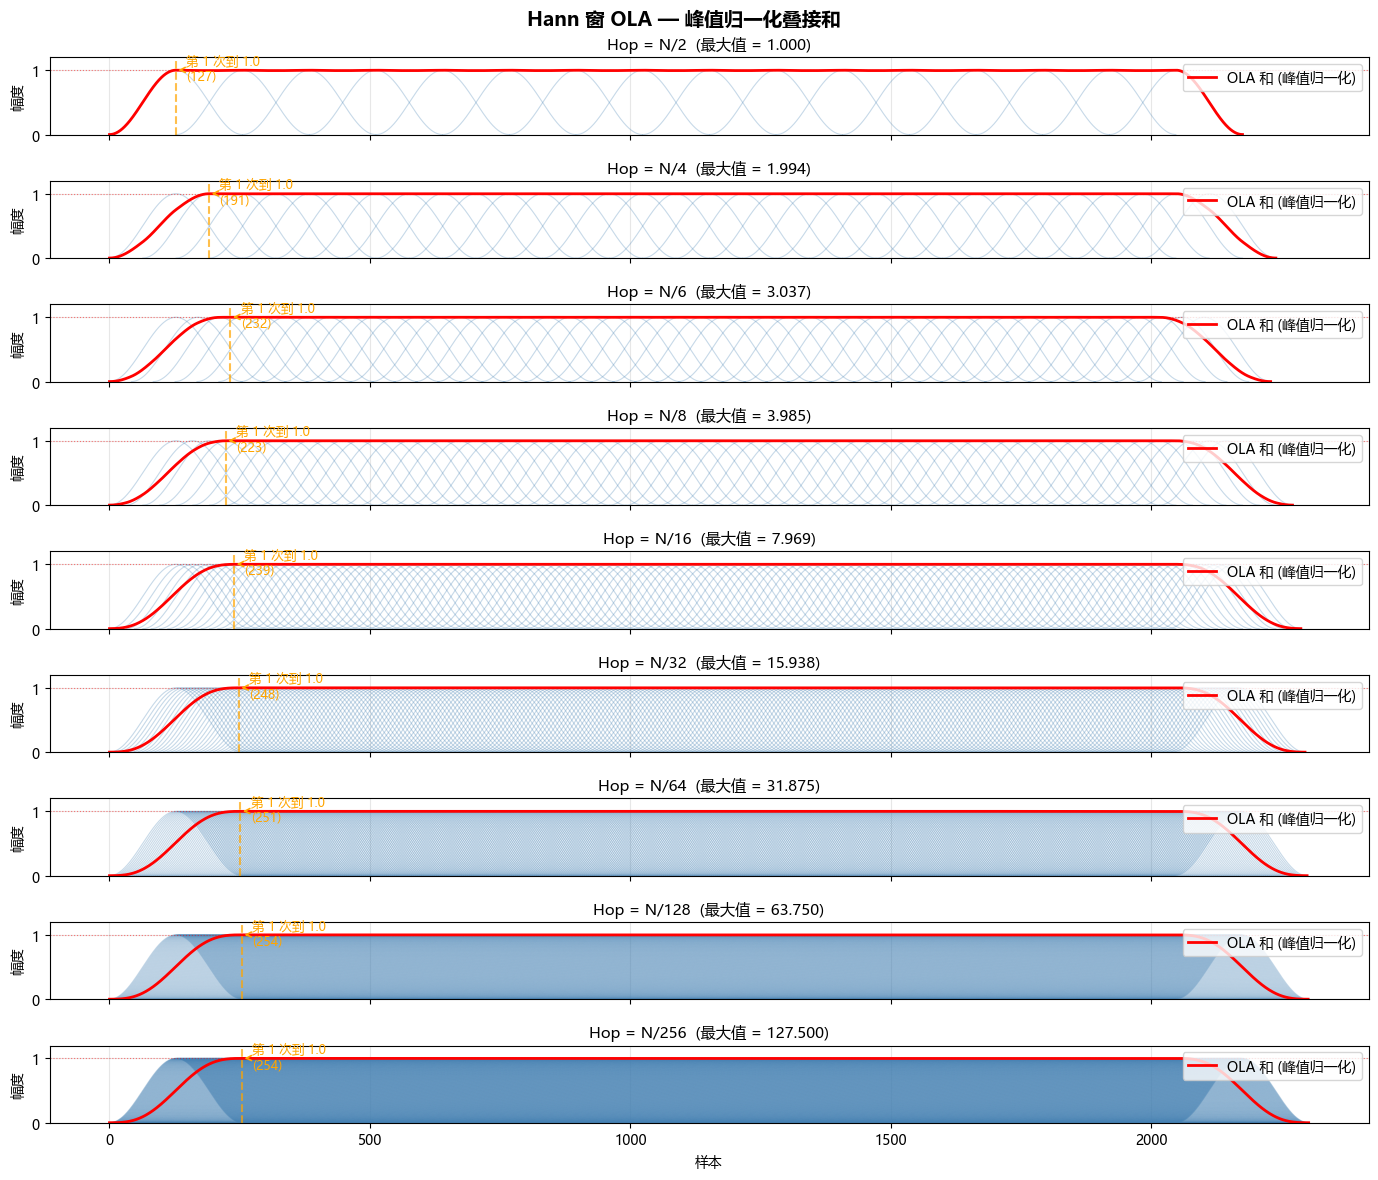

--- 峰值归一化 OLA 和特性 ---
     Hop     首次到 1.0       最大值       最小值       比值(最大/最小)
------------------------------------------------------
     N/2         127     1.000     0.994            1.01
     N/4         191     1.994     0.503            3.96
     N/6         232     3.037     0.245           12.41
     N/8         223     3.985     0.148           27.01
    N/16         239     7.969     0.038          207.77
    N/32         248    15.938     0.010         1646.01
    N/64         251    31.875     0.002        13135.99
   N/128         254    63.750     0.001       105024.04
   N/256         254   127.500     0.000       840064.77


In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DengXian']
plt.rcParams['axes.unicode_minus'] = False

M = 256        # 窗长
R_values = [2, 4, 6, 8, 16, 32, 64, 128, 256]
hop_labels = [f'N/{r}' for r in R_values]

win = np.hanning(M)

fig, axes = plt.subplots(len(R_values), 1, figsize=(14, 12), sharex=True)

for idx, (R, label) in enumerate(zip(R_values, hop_labels)):
    ax = axes[idx]
    hop = M // R
    num_windows = R * 8
    total_len = hop * (num_windows - 1) + M
    ola_sum = np.zeros(total_len)

    for w in range(num_windows):
        pos = w * hop
        ola_sum[pos:pos + M] += win
        ax.plot(np.arange(pos, pos + M), win, color='steelblue', alpha=0.3, linewidth=0.8)

    # 归一化到最大值 = 1.0
    ola_norm = ola_sum / ola_sum.max()

    # 找第一次达到 1.0 的位置
    first_one = np.argmax(ola_norm >= 1.0)

    ax.plot(ola_norm, color='red', linewidth=2, label='OLA 和 (峰值归一化)')
    ax.axhline(y=1.0, color='red', ls=':', lw=0.8, alpha=0.5)
    ax.axvline(x=first_one, color='orange', ls='--', lw=1.5, alpha=0.7)
    ax.annotate(f'第 1 次到 1.0\n({first_one})', xy=(first_one, 1.0),
                xytext=(first_one + 20, 0.85), fontsize=9, color='orange',
                arrowprops=dict(arrowstyle='->', color='orange', lw=1.2))
    ax.set_title(f'Hop = {label}  (最大值 = {ola_sum.max():.3f})', fontsize=11)
    ax.set_ylabel('幅度')
    ax.set_ylim(0, 1.2)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('样本')
fig.suptitle('Hann 窗 OLA — 峰值归一化叠接和', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('--- 峰值归一化 OLA 和特性 ---')
print(f'{"Hop":>8s}  {"首次到 1.0":>10s}  {"最大值":>8s}  {"最小值":>8s}  {"比值(最大/最小)":>14s}')
print('-' * 54)
for R, label in zip(R_values, hop_labels):
    hop = M // R
    nw = R * 8
    total_len = hop * (nw - 1) + M
    ola = np.zeros(total_len)
    for w in range(nw):
        ola[w*hop:w*hop + M] += win
    ola_norm = ola / ola.max()
    first_one = np.argmax(ola_norm >= 1.0)
    steady = ola[hop:total_len - M]
    mx = steady.max()
    mn = steady.min()
    ratio = mx / mn if mn > 0 else float('inf')
    print(f'{label:>8s}  {first_one:>10d}  {mx:>8.3f}  {mn:>8.3f}  {ratio:>14.2f}')